In [1]:
# Import necessary libraries
import kagglehub
from kagglehub import KaggleDatasetAdapter
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import collections
from collections import Counter
import re
from sklearn.preprocessing import MultiLabelBinarizer
from tqdm import tqdm

# Set the style for the plots
plt.style.use('ggplot')
sns.set(style="whitegrid")

# For reproducibility
np.random.seed(42)

pd.set_option('display.max_colwidth', 200)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading data from Kaggle

In [2]:
# Load data
edges = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jfreyberg/spotify-artist-feature-collaboration-network",
  "edges.csv"
)

nodes = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jfreyberg/spotify-artist-feature-collaboration-network",
  "nodes.csv"
)

/tmp/ipykernel_85868/2056443041.py:2: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  edges = kagglehub.load_dataset(


/tmp/ipykernel_85868/2056443041.py:8: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  nodes = kagglehub.load_dataset(


In [3]:
# Select Artists with chart hits
selected_nodes = nodes[nodes['chart_hits'].notna()].reset_index(drop=True)

# Select edges for the selected nodes
selected_edges = edges[edges['id_0'].isin(selected_nodes['spotify_id']) & edges['id_1'].isin(selected_nodes['spotify_id'])].reset_index(drop=True)

In [4]:
# Create a graph from the selected edges
G = nx.from_pandas_edgelist(selected_edges, source='id_0', target='id_1')

In [5]:
# Find the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
print(f"Size of the largest connected component: {len(largest_cc)}")

# Create a subgraph of the largest connected component
G_lcc = G.subgraph(largest_cc).copy()
print(f"Largest connected component has {G_lcc.number_of_nodes()} nodes and {G_lcc.number_of_edges()} edges")

Size of the largest connected component: 13450
Largest connected component has 13450 nodes and 71946 edges


## Prepare node features

In [6]:
# For large networks, computing centrality measures can be time-consuming
# We'll work with the largest connected component for this analysis

# Calculate degree centrality
degree_centrality = nx.degree_centrality(G_lcc)

# Calculate betweenness centrality (this might take some time)
print("Computing betweenness centrality (this might take a while)...")
# Use approximate betweenness with sampling for large networks
betweenness_centrality = nx.betweenness_centrality(G_lcc, k=1000, normalized=True, seed=42)

# Calculate closeness centrality
print("Computing closeness centrality...")
closeness_centrality = nx.closeness_centrality(G_lcc)

Computing betweenness centrality (this might take a while)...


Computing closeness centrality...


## Link Prediction

In [6]:
# Link Prediction using DGL
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
import dgl.function as fn
from dgl.nn import GraphConv
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import random

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [7]:
print(f"Using {G_lcc.number_of_nodes()} nodes and {G_lcc.number_of_edges()} edges")

Using 13450 nodes and 71946 edges


In [20]:
# Create node features
node_features = {}
# Pre-compute all centrality measures and clustering coefficients once.
deg_cent_all = degree_centrality
bet_cent_all = betweenness_centrality
close_cent_all = closeness_centrality
clustering_all = nx.clustering(G_lcc)

# Compute node features for each node using the pre-computed values.
for node in G_lcc.nodes():
    degree = G_lcc.degree(node)
    clustering = clustering_all[node]
    followers = selected_nodes.query("spotify_id == @node").iloc[0]['followers']

    node_features[node] = [
        degree,
        clustering,
        deg_cent_all[node],
        bet_cent_all[node],
        close_cent_all[node],
        float(followers)
    ]

# Create a node mapping
node_mapping = {node: i for i, node in enumerate(G_lcc.nodes())}
reverse_mapping = {i: node for node, i in node_mapping.items()}

# Get all edges and split them
all_edges = list(G_lcc.edges())

random.seed(41)
random.shuffle(all_edges)

# Split edges into train/val/test
n_edges = len(all_edges)
train_edges = all_edges[:int(0.7*n_edges)]
val_edges = all_edges[int(0.7*n_edges):int(0.85*n_edges)]
test_edges = all_edges[int(0.85*n_edges):]

print(f"Train edges: {len(train_edges)}, Val edges: {len(val_edges)}, Test edges: {len(test_edges)}")

Train edges: 50362, Val edges: 10792, Test edges: 10792


In [21]:
# Create a graph with only training edges
train_graph = G_lcc.copy()
train_graph.remove_edges_from(val_edges + test_edges)

# Create negative samples for validation and testing
def create_negative_edges(graph, n_samples, existing_edges):
    nodes = list(graph.nodes())
    negative_edges = []
    existing_edge_set = set(existing_edges + [(v, u) for u, v in existing_edges])  # Include both directions
    
    while len(negative_edges) < n_samples:
        u, v = random.sample(nodes, 2)
        if (u, v) not in existing_edge_set and (v, u) not in existing_edge_set and (u, v) not in negative_edges:
            negative_edges.append((u, v))
    
    return negative_edges

val_neg_edges = create_negative_edges(G_lcc, len(val_edges), train_edges + test_edges)
test_neg_edges = create_negative_edges(G_lcc, len(test_edges), train_edges + val_edges + val_neg_edges)

# Create feature matrix for nodes
features = np.array([node_features[node] for node in G_lcc.nodes()])
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert to DGL graph
edges_src = []
edges_dst = []

for u, v in train_graph.edges():
    edges_src.append(node_mapping[u])
    edges_dst.append(node_mapping[v])
    # For undirected graphs, add the reverse edge
    edges_src.append(node_mapping[v])
    edges_dst.append(node_mapping[u])

dgl_graph = dgl.graph((torch.tensor(edges_src), torch.tensor(edges_dst)))
dgl_graph.ndata['feat'] = torch.FloatTensor(features_scaled)

# Convert the edge sets for DGL
def convert_edge_sets(edge_list, node_mapping):
    src = [node_mapping[u] for u, v in edge_list]
    dst = [node_mapping[v] for u, v in edge_list]
    return torch.tensor(src), torch.tensor(dst)

val_pos_src, val_pos_dst = convert_edge_sets(val_edges, node_mapping)
val_neg_src, val_neg_dst = convert_edge_sets(val_neg_edges, node_mapping)
test_pos_src, test_pos_dst = convert_edge_sets(test_edges, node_mapping)
test_neg_src, test_neg_dst = convert_edge_sets(test_neg_edges, node_mapping)

# Define the Link Prediction model using GraphConv
class LinkPrediction(nn.Module):
    def __init__(self, in_feats, h_feats):
        super(LinkPrediction, self).__init__()
        self.conv1 = GraphConv(in_feats, h_feats, allow_zero_in_degree=True)
        self.conv2 = GraphConv(h_feats, h_feats, allow_zero_in_degree=True)
        self.predict = nn.Sequential(
            nn.Linear(h_feats * 2, h_feats),
            nn.ReLU(),
            nn.Linear(h_feats, 1)
        )
    
    def forward(self, g, h):
        # Get node embeddings
        h = F.relu(self.conv1(g, h))
        h = self.conv2(g, h)
        return h
    
    def predict_link(self, h, src, dst):
        # Get embeddings for source and destination nodes
        h_src = h[src]
        h_dst = h[dst]
        # Concatenate embeddings and predict link probability
        h_concat = torch.cat([h_src, h_dst], dim=1)
        return torch.sigmoid(self.predict(h_concat)).squeeze()

In [23]:
# Create the model
in_feats = features_scaled.shape[1]
h_feats = 32  # Hidden dimension size
model = LinkPrediction(in_feats, h_feats)

# Move everything to device
model = model.to(device)
dgl_graph = dgl_graph.to(device)
features = dgl_graph.ndata['feat'].to(device)
val_pos_src = val_pos_src.to(device)
val_pos_dst = val_pos_dst.to(device)
val_neg_src = val_neg_src.to(device)
val_neg_dst = val_neg_dst.to(device)
test_pos_src = test_pos_src.to(device)
test_pos_dst = test_pos_dst.to(device)
test_neg_src = test_neg_src.to(device)
test_neg_dst = test_neg_dst.to(device)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Define the loss function
loss_fn = nn.BCELoss()

# Training loop
best_val_auc = 0
best_model = None
patience = 20
counter = 0

print("\nTraining Link Prediction model...")
for epoch in range(200):
    model.train()
    
    # Forward pass
    h = model(dgl_graph, features)
    
    # Positive and negative samples for this epoch
    # Sample edges from training graph
    train_pos_src, train_pos_dst = dgl_graph.edges()
    # Use the sampled edges as positive samples, sample same number of negatives
    n_edges_to_sample = min(len(train_pos_src), 1000)  # Limit batch size
    idx = torch.randperm(len(train_pos_src))[:n_edges_to_sample]
    train_pos_src, train_pos_dst = train_pos_src[idx], train_pos_dst[idx]
    
    # Create negative samples
    train_neg_src = train_pos_src
    train_neg_dst = torch.randint(0, dgl_graph.number_of_nodes(), (n_edges_to_sample,), device=device)
    
    # Filter out existing edges from negative samples
    edge_set = set(zip(train_pos_src.cpu().numpy(), train_pos_dst.cpu().numpy()))
    neg_edges = []
    for i in range(len(train_neg_src)):
        src, dst = train_neg_src[i].item(), train_neg_dst[i].item()
        if (src, dst) not in edge_set and src != dst:
            neg_edges.append(i)
    
    train_neg_src = train_neg_src[neg_edges]
    train_neg_dst = train_neg_dst[neg_edges]
    
    # Make sure we have same number of positive and negative samples
    min_size = min(len(train_pos_src), len(train_neg_src))
    train_pos_src, train_pos_dst = train_pos_src[:min_size], train_pos_dst[:min_size]
    train_neg_src, train_neg_dst = train_neg_src[:min_size], train_neg_dst[:min_size]
    
    # Predict on positive and negative samples
    pos_score = model.predict_link(h, train_pos_src, train_pos_dst)
    neg_score = model.predict_link(h, train_neg_src, train_neg_dst)
    
    # Compute loss
    pos_loss = loss_fn(pos_score, torch.ones_like(pos_score))
    neg_loss = loss_fn(neg_score, torch.zeros_like(neg_score))
    loss = pos_loss + neg_loss
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        h = model(dgl_graph, features)
        val_pos_score = model.predict_link(h, val_pos_src, val_pos_dst)
        val_neg_score = model.predict_link(h, val_neg_src, val_neg_dst)
        
        # Calculate validation AUC
        val_labels = torch.cat([torch.ones_like(val_pos_score), torch.zeros_like(val_neg_score)]).cpu().numpy()
        val_preds = torch.cat([val_pos_score, val_neg_score]).cpu().numpy()
        val_auc = roc_auc_score(val_labels, val_preds)
        
        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model = {key: value.cpu() for key, value in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
        
        # Early stopping
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        train_auc = roc_auc_score(
            torch.cat([torch.ones_like(pos_score), torch.zeros_like(neg_score)]).cpu().numpy(),
            torch.cat([pos_score, neg_score]).detach().cpu().numpy()
        )
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}")


Training Link Prediction model...
Epoch 000 | Loss: 1.3699 | Train AUC: 0.7121 | Val AUC: 0.7481
Epoch 010 | Loss: 1.0328 | Train AUC: 0.8105 | Val AUC: 0.6613
Epoch 020 | Loss: 0.9354 | Train AUC: 0.8497 | Val AUC: 0.7731
Epoch 030 | Loss: 0.8789 | Train AUC: 0.8763 | Val AUC: 0.8093
Epoch 040 | Loss: 0.8540 | Train AUC: 0.8840 | Val AUC: 0.8187
Epoch 050 | Loss: 0.7960 | Train AUC: 0.8966 | Val AUC: 0.8098
Epoch 060 | Loss: 0.7986 | Train AUC: 0.8962 | Val AUC: 0.8197
Epoch 070 | Loss: 0.7613 | Train AUC: 0.9050 | Val AUC: 0.8295
Epoch 080 | Loss: 0.7499 | Train AUC: 0.9065 | Val AUC: 0.8223
Early stopping at epoch 82


In [24]:
# Load the best model
if best_model is not None:
    model.load_state_dict(best_model)
    model = model.to(device)

# Evaluate on test set
model.eval()
with torch.no_grad():
    h = model(dgl_graph, features)
    test_pos_score = model.predict_link(h, test_pos_src, test_pos_dst)
    test_neg_score = model.predict_link(h, test_neg_src, test_neg_dst)
    
    # Calculate test metrics
    test_labels = torch.cat([torch.ones_like(test_pos_score), torch.zeros_like(test_neg_score)]).cpu().numpy()
    test_preds = torch.cat([test_pos_score, test_neg_score]).cpu().numpy()
    test_auc = roc_auc_score(test_labels, test_preds)
    
    # Binary predictions for other metrics
    test_binary_preds = (test_preds > 0.5).astype(int)
    test_acc = accuracy_score(test_labels, test_binary_preds)

print("\nDGL Link Prediction Results:")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_binary_preds))


DGL Link Prediction Results:
Test Accuracy: 0.7548
Test AUC: 0.8262

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.76      0.76     10792
         1.0       0.76      0.75      0.75     10792

    accuracy                           0.75     21584
   macro avg       0.75      0.75      0.75     21584
weighted avg       0.75      0.75      0.75     21584



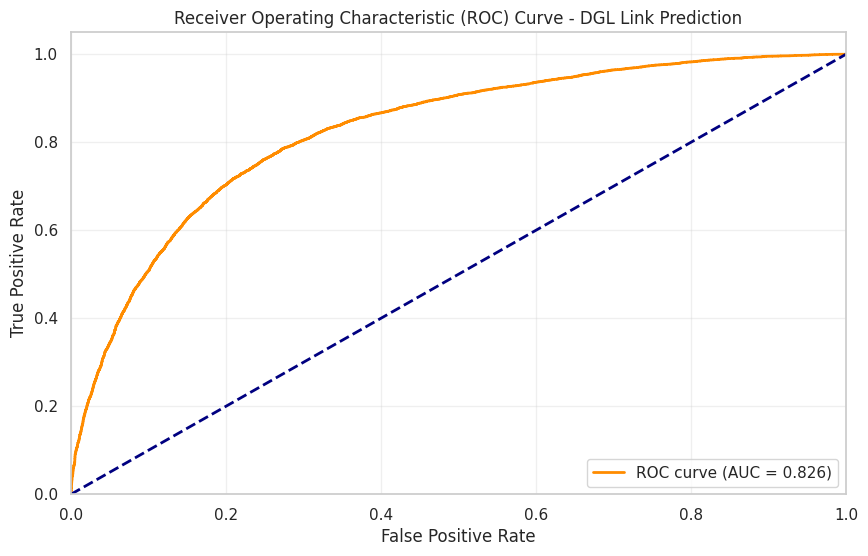

In [25]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_preds)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - DGL Link Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Case Study

In [18]:
def show_artist(node_id):
    display(selected_nodes.query("spotify_id == @node_id"))
    target_node = node_id
    # Find the row in selected_nodes where spotify_id matches node_id
    subgraph = nx.ego_graph(G_lcc, target_node, radius=1)

    # Plot the subgraph
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(subgraph)  # Layout for visualization

    # Draw node labels using the Artist Name
    id_to_name = dict(zip(selected_nodes['spotify_id'], selected_nodes['name']))
    labels = {node: id_to_name.get(node, node) for node in subgraph.nodes()}

    # Draw the subgraph
    nx.draw(
        subgraph,
        pos,
        labels=labels,
        node_color=['lightblue' if n == target_node else 'lightgray' for n in subgraph.nodes()],
        node_size=500,
        font_size=9,
        edge_color='gray'
    )

    plt.title(f"Subgraph centered on artist {labels[target_node]}")
    plt.show()

In [27]:
selected_nodes['id'] = selected_nodes['spotify_id'].map(node_mapping)

In [28]:
selected_nodes.query("name.str.find('Bruno Mars').values > -1")

,spotify_id,name,followers,popularity,genres,chart_hits,id
12282,0du5cEVh5yTK9QJze8zA0C,Bruno Mars,43103624.0,87,"['dance pop', 'pop']","['us (24)', 'gb (19)', 'ar (12)', 'au (17)', 'at (11)', 'be (15)', 'bo (10)', 'br (12)', 'bg (8)', 'ca (25)', 'cl (15)', 'co (11)', 'cr (21)', 'cy (8)', 'cz (10)', 'dk (19)', 'do (19)', 'ec (12)',...",2289.0


,spotify_id,name,followers,popularity,genres,chart_hits
12282,0du5cEVh5yTK9QJze8zA0C,Bruno Mars,43103624.0,87,"['dance pop', 'pop']","['us (24)', 'gb (19)', 'ar (12)', 'au (17)', 'at (11)', 'be (15)', 'bo (10)', 'br (12)', 'bg (8)', 'ca (25)', 'cl (15)', 'co (11)', 'cr (21)', 'cy (8)', 'cz (10)', 'dk (19)', 'do (19)', 'ec (12)',..."


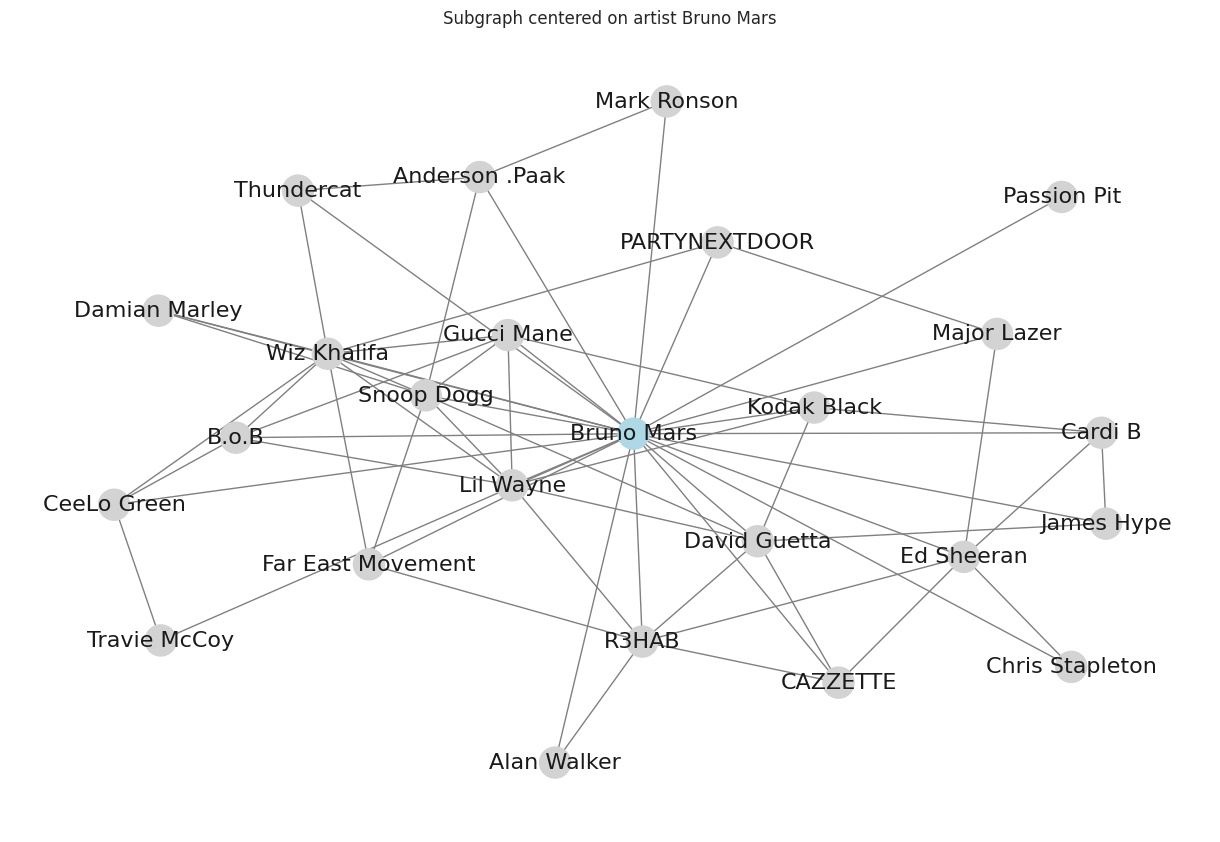

In [11]:
show_artist('0du5cEVh5yTK9QJze8zA0C')

,spotify_id,name,followers,popularity,genres,chart_hits
1048,3eVa5w3URK5duf6eyVDbu9,ROSÉ,3244912.0,64,['k-pop'],"['us (1)', 'gb (1)', 'au (2)', 'at (1)', 'bo (1)', 'br (2)', 'bg (2)', 'ca (2)', 'cl (2)', 'co (2)', 'cr (1)', 'cy (1)', 'cz (1)', 'ec (1)', 'eg (1)', 'sv (2)', 'ee (1)', 'fi (1)', 'fr (1)', 'de (..."


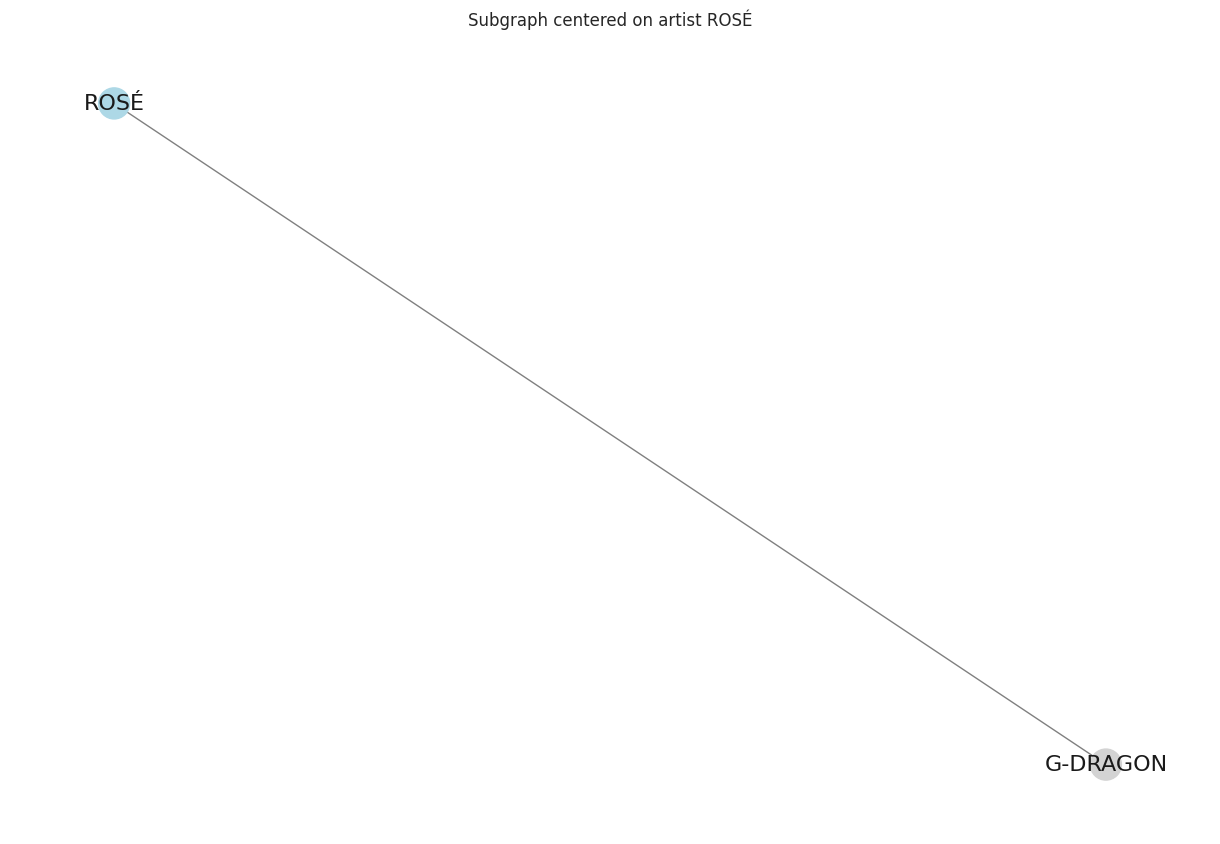

In [12]:
show_artist('3eVa5w3URK5duf6eyVDbu9')

In [31]:
model.predict_link(h, [2289], [9265]).cpu().detach().numpy()

array(0.01649949, dtype=float32)

# All 

In [32]:
selected_edges['id_0_id'] = selected_edges['id_0'].map(node_mapping)
selected_edges['id_1_id'] = selected_edges['id_1'].map(node_mapping)

In [63]:
selected_nodes.query("name.str.find('Taylor Swift').values > -1")

,spotify_id,name,followers,popularity,genres,chart_hits,id
4638,06HL4z0CvFAxyc27GXpf02,Taylor Swift,58554324.0,94,['pop'],"['us (136)', 'gb (115)', 'ar (24)', 'au (110)', 'at (36)', 'be (54)', 'bo (12)', 'br (40)', 'bg (49)', 'ca (121)', 'cl (11)', 'co (16)', 'cr (28)', 'cy (43)', 'cz (28)', 'dk (39)', 'do (14)', 'ec ...",1040.0


,spotify_id,name,followers,popularity,genres,chart_hits
4638,06HL4z0CvFAxyc27GXpf02,Taylor Swift,58554324.0,94,['pop'],"['us (136)', 'gb (115)', 'ar (24)', 'au (110)', 'at (36)', 'be (54)', 'bo (12)', 'br (40)', 'bg (49)', 'ca (121)', 'cl (11)', 'co (16)', 'cr (28)', 'cy (43)', 'cz (28)', 'dk (39)', 'do (14)', 'ec ..."


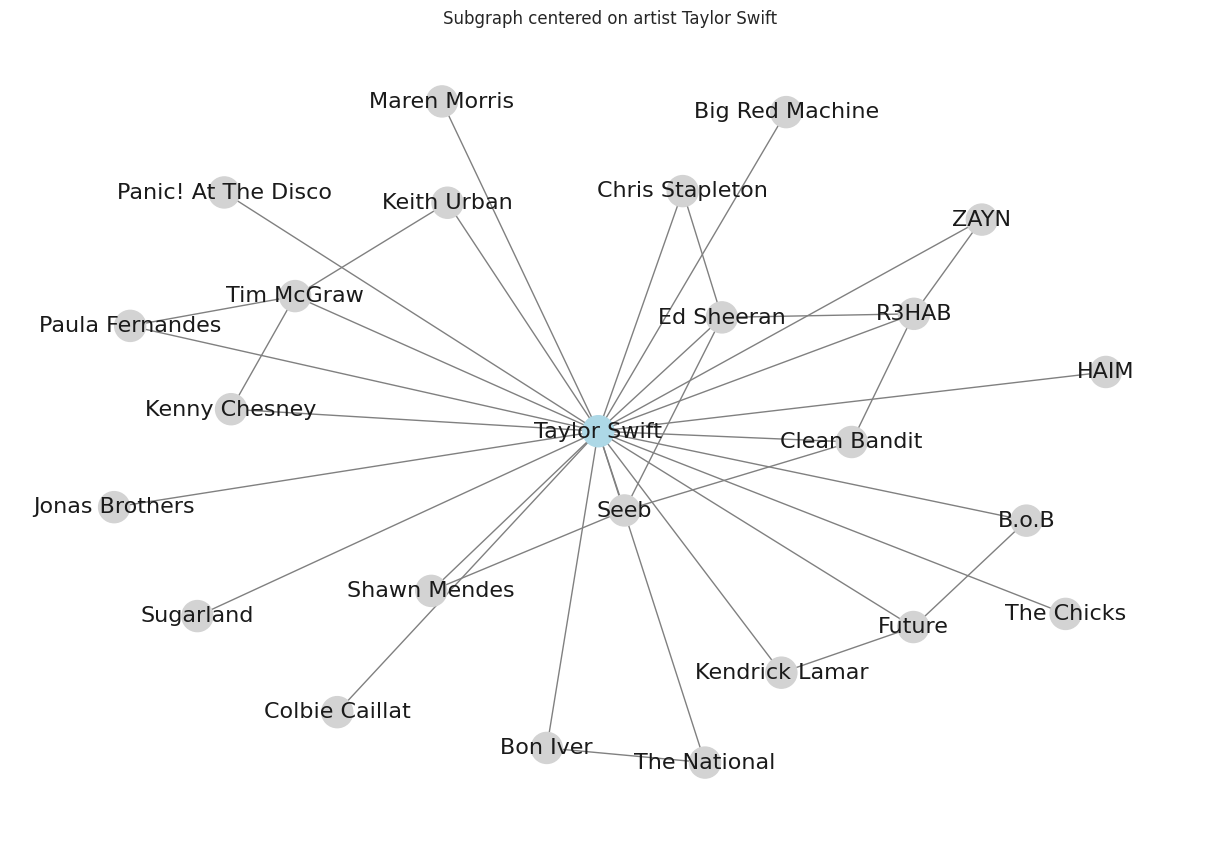

In [13]:
show_artist('06HL4z0CvFAxyc27GXpf02')

In [65]:
target_id = 1040
already_colab_list = selected_edges[selected_edges['id_0_id'] == target_id]['id_1_id'].to_list()
all_other_list = [id for id in reverse_mapping.keys() if id not in already_colab_list and id != target_id]

model.eval()
with torch.no_grad():
    h = model(dgl_graph, features)
    test_score = model.predict_link(h, [target_id] * len(all_other_list), all_other_list)

In [66]:
pd.DataFrame(dict(zip(list(all_other_list), test_score.cpu().numpy())), index=['Probability']).T.sort_values('Probability', ascending=False).head(5)

,Probability
259,0.999274
924,0.999079
418,0.998931
60,0.998817
97,0.998749


In [67]:
pd.DataFrame(dict(zip(list(all_other_list), test_score.cpu().numpy())), index=['Probability']).T.sort_values('Probability', ascending=True).head(5)

,Probability
8169,2.533773e-13
7493,1.868281e-12
3324,5.340622e-12
9456,5.476613e-12
11224,4.769569e-11


,spotify_id,name,followers,popularity,genres,chart_hits
4257,7c0XG5cIJTrrAgEC3ULPiq,Ty Dolla $ign,4339428.0,81,"['dance pop', 'hip hop', 'pop', 'pop rap', 'r&b', 'southern hip hop', 'trap', 'trap soul', 'urban contemporary']","['us (18)', 'gb (2)', 'au (5)', 'at (2)', 'be (2)', 'bg (12)', 'ca (17)', 'cy (3)', 'cz (2)', 'dk (4)', 'ee (4)', 'fi (3)', 'fr (1)', 'de (3)', 'gr (7)', 'hk (2)', 'hu (5)', 'is (2)', 'ie (2)', 'i..."


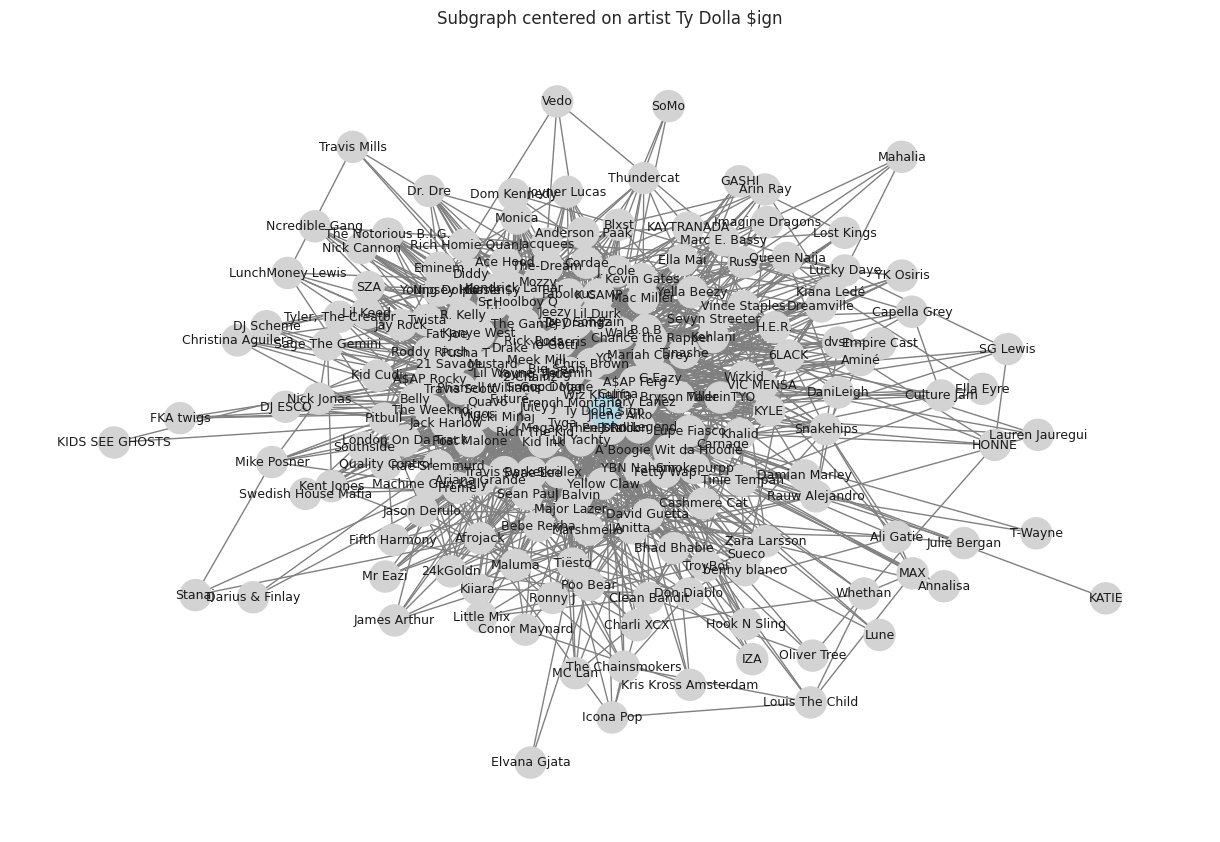

In [19]:
show_artist(reverse_mapping[259])

,spotify_id,name,followers,popularity,genres,chart_hits
15306,14DnMswKGQIr7vgwyiiLKI,Remis Retro,4260.0,33,"['lithuanian hip hop', 'lithuanian pop', 'lithuanian trap']",['lt (5)']


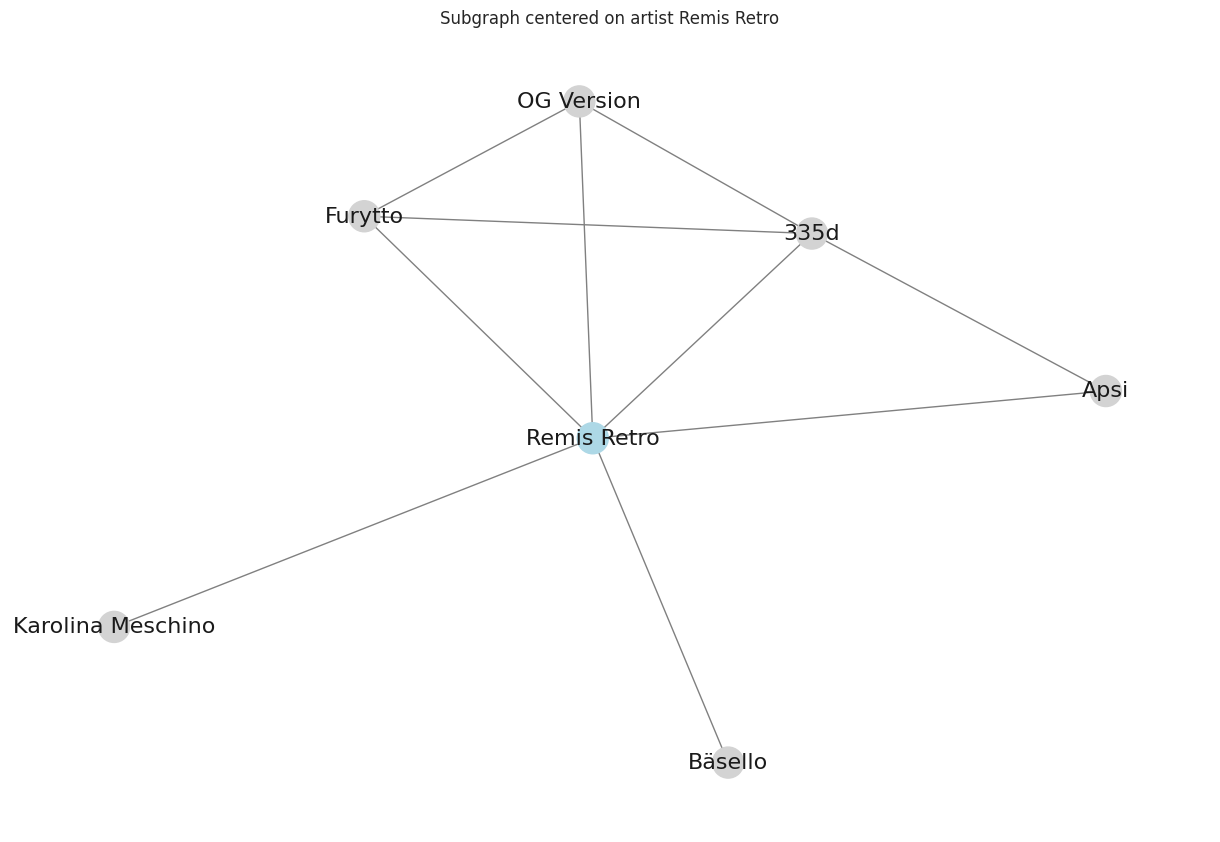

In [17]:
show_artist(reverse_mapping[8169])